In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

import os

## 1. Dataset loading and cleaning

In [2]:
#import the telco churn data:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

/Users/jakubromanczuk/Dev/Duke/xai/Assumption-junction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/jakubromanczuk/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [3]:
df_raw = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))
display(df_raw.head())
display(df_raw.dtypes)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
# chaning TotalCharges type to float as it is currently a str
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors="coerce").fillna(0)


In [5]:
# Checking if customer id is unique and we can remove it
print(df_raw["customerID"].nunique(), len(df_raw))

7043 7043


In [6]:
df = df.drop('customerID', axis=1)

In [7]:
# checking string type values to see data structure
for col in df.select_dtypes(include="str"):
    print(col, "->", df[col].unique())

gender -> <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines -> <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService -> <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup -> <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract -> <StringArray>
['Mont

In [8]:
# checking cross reference of PhoneService vs Multiple lines and InternetService vs OnlineSecurity
# to see if we can, e.g. No is correlated to "No phone service"
display(pd.crosstab(df["PhoneService"], df["MultipleLines"]))
display(pd.crosstab(df["InternetService"], df["OnlineSecurity"]))

MultipleLines,No,No phone service,Yes
PhoneService,,,
No,0,682,0
Yes,3390,0,2971


OnlineSecurity,No,No internet service,Yes
InternetService,,,
DSL,1241,0,1180
Fiber optic,2257,0,839
No,0,1526,0


We can replace MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies" we can "No phone" and "No internet service" for these because those values are indetical as the PhoneService NO and Internet Service no

In [9]:
service_cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df[service_cols] = df[service_cols].replace(
    {"No internet service": "No", "No phone service": "No"}
)


In [10]:
# last change maping churn to 1/0 and seeing the data distribution
df['Churn'] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())
print(df["Churn"].mean())

Churn
0    5174
1    1869
Name: count, dtype: int64
0.2653698707936959


### Data structure at the end of step 1

In [11]:
display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2. EDA: Logistic Regression Assumption

### Independence of observations

Every row is a different customer — customerID is unique, so nobody appears twice. The tests listed for this assumption look for patterns between consecutive rows, which only makes sense for data collected in order over time. This data is a single snapshot of separate customers in no particular order, so those tests don't apply.

### No perfect separation

In [12]:
for col in df.select_dtypes(include="str").columns:
    print(pd.crosstab(df[col], df["Churn"]), "\n")

Churn      0    1
gender           
Female  2549  939
Male    2625  930 

Churn       0     1
Partner            
No       2441  1200
Yes      2733   669 

Churn          0     1
Dependents            
No          3390  1543
Yes         1784   326 

Churn            0     1
PhoneService            
No             512   170
Yes           4662  1699 

Churn             0     1
MultipleLines            
No             3053  1019
Yes            2121   850 

Churn               0     1
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113 

Churn              0     1
OnlineSecurity            
No              3450  1574
Yes             1724   295 

Churn            0     1
OnlineBackup            
No            3268  1346
Yes           1906   523 

Churn                0     1
DeviceProtection            
No                3297  1324
Yes               1877   545 

Churn           0     1
TechSupport            
No           3440  155

Above returned 0 in no cell. It means that theres no separation. 

### Linear log-odds

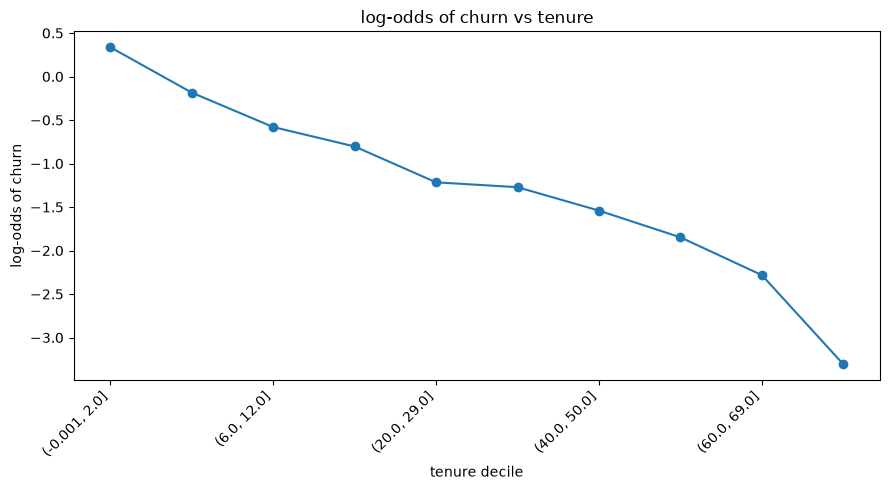

In [13]:
# Linearity of the logit (tenure)
tenureBins = pd.qcut(df["tenure"], 10)
tenureRate = df.groupby(tenureBins, observed=True)["Churn"].mean()
tenureLogit = np.log(tenureRate / (1 - tenureRate))

tenureLogit.plot(marker="o", figsize=(9, 5))
plt.ylabel("log-odds of churn")
plt.xlabel("tenure decile")
plt.title("log-odds of churn vs tenure")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

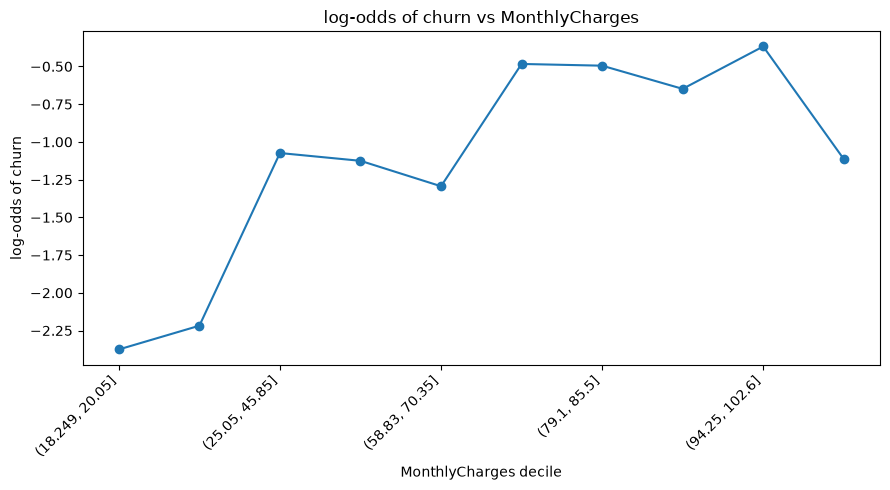

In [14]:
# Linearity of the logit (MonthlyCharges)
monthlyBins = pd.qcut(df["MonthlyCharges"], 10)
monthlyRate = df.groupby(monthlyBins, observed=True)["Churn"].mean()
monthlyLogit = np.log(monthlyRate / (1 - monthlyRate))

monthlyLogit.plot(marker="o", figsize=(9, 5))
plt.ylabel("log-odds of churn")
plt.xlabel("MonthlyCharges decile")
plt.title("log-odds of churn vs MonthlyCharges")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


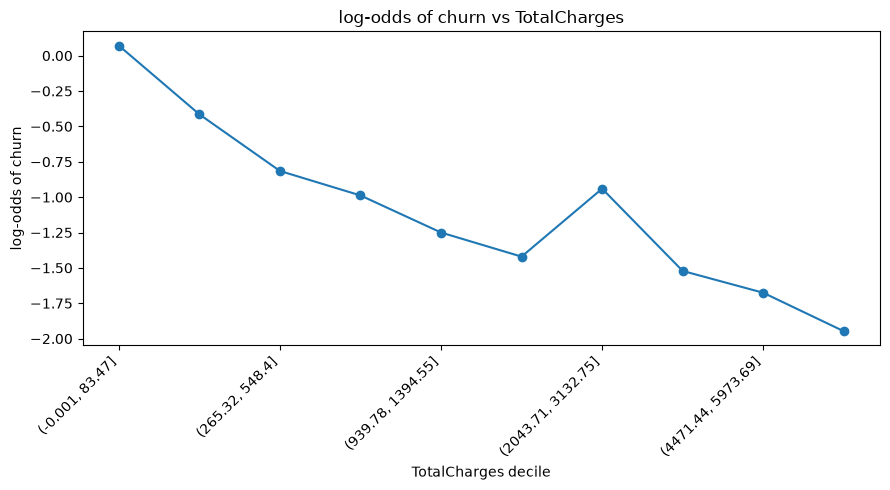

In [15]:
# Linearity of the logit (TotalCharges)
monthlyBins = pd.qcut(df["TotalCharges"], 10)
monthlyRate = df.groupby(monthlyBins, observed=True)["Churn"].mean()
monthlyLogit = np.log(monthlyRate / (1 - monthlyRate))

monthlyLogit.plot(marker="o", figsize=(9, 5))
plt.ylabel("log-odds of churn")
plt.xlabel("TotalCharges decile")
plt.title("log-odds of churn vs TotalCharges")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Limited multicollinearity.

In [16]:
num = df[["tenure", "MonthlyCharges", "TotalCharges"]]
vif = pd.DataFrame({
    "feature": num.columns,
    "VIF": [variance_inflation_factor(num.values, i) for i in range(num.shape[1])]
})
print(vif)
print(num.corr())

          feature       VIF
0          tenure  5.836728
1  MonthlyCharges  3.216730
2    TotalCharges  9.510931
                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000


VIF on the three continuous predictors: TotalCharges 9.51, tenure 5.84, MonthlyCharges 3.22. The TotalCharges is approaching 10 treshold.

In [17]:
# check what VIF looks like without TotalCharges
num2 = df[["tenure", "MonthlyCharges"]]
print(pd.DataFrame({
    "feature": num2.columns,
    "VIF": [variance_inflation_factor(num2.values, i) for i in range(num2.shape[1])]
}))

          feature       VIF
0          tenure  1.065478
1  MonthlyCharges  1.065478


VIF shows no correlation between tenure and montlhy changes after removing TotalCharges. We can safely remove it the dataframe.

In [18]:
df = df.drop(columns=["TotalCharges"])

In [19]:
# one-hot encoding for str values
n_events = df["Churn"].sum()
n_pred = pd.get_dummies(df, drop_first=True).shape[1]

### SECTION 2 summarization:
Assumption |	Verdict
Binary outcome	| Satisfied
Independence|	Assumed; single snapshot, one row per customer, no household identifier to verify
No perfect separation	Satisfied — min cell [N]
Linear log-odds	Violated for MonthlyCharges (non-monotonic); satisfied for tenure
Multicollinearity	Violated — TotalCharges VIF 9.51, dropped; remaining VIFs 1.07
Sample size	Satisfied — 71.9 events/predictor

In [20]:
# Data frame after section 2
display(df.head())
print(f"Shape of DF {df.shape}")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1


Shape of DF (7043, 19)


## 3 Model

In [21]:
# Prepare data
X = df.drop(columns=["Churn"])
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True, dtype=int)
print(X.shape)
print(X.columns.tolist())

(7043, 22)
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [22]:
# Split training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(5634, 22) (1409, 22)
0.2653532126375577 0.2654364797728886


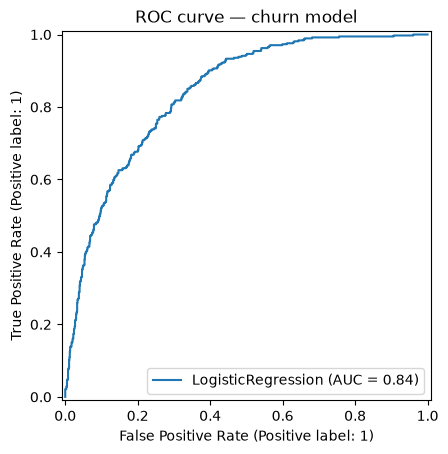

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC curve — churn model")
plt.legend()
plt.show()

In [24]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("baseline (always predict 'no churn'):", round(1 - y_test.mean(), 3))
print("accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

baseline (always predict 'no churn'): 0.735
accuracy: 0.796
ROC-AUC: 0.839
[[919 116]
 [172 202]]
              precision    recall  f1-score   support

           0      0.842     0.888     0.865      1035
           1      0.635     0.540     0.584       374

    accuracy                          0.796      1409
   macro avg      0.739     0.714     0.724      1409
weighted avg      0.787     0.796     0.790      1409



Baseline - 0,735 vs model's accuraccly - 0.796

## 5. Coefficient

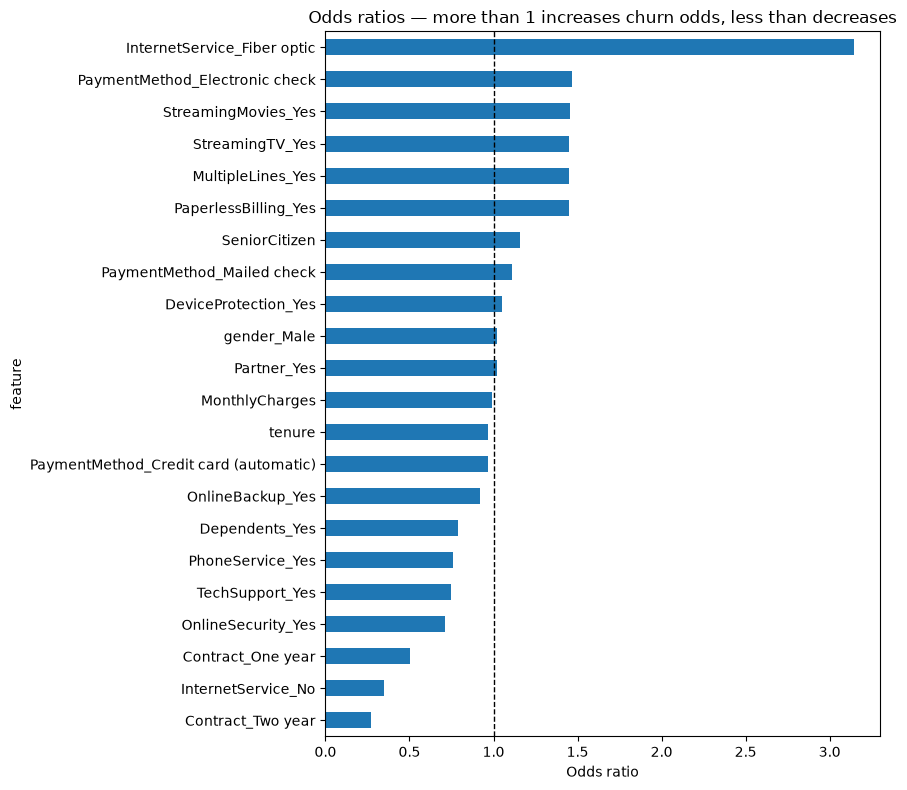

In [25]:
coefs = pd.DataFrame({
    "feature": model.feature_names_in_,
    "coef": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0])
}).sort_values("coef")
plot_df = coefs.set_index("feature")["odds_ratio"].sort_values()

plt.figure(figsize=(9, 8))
plot_df.plot(kind="barh")
plt.axvline(1.0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Odds ratio")
plt.title("Odds ratios — more than 1 increases churn odds, less than decreases")
plt.tight_layout()
plt.show()

In [26]:
coefs = pd.DataFrame({
    "feature": model.feature_names_in_,
    "coef": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0])
}).sort_values("coef")
print(coefs.to_string())

                                  feature      coef  odds_ratio
17                      Contract_Two year -1.311628    0.269381
9                      InternetService_No -1.050703    0.349692
16                      Contract_One year -0.685897    0.503638
10                     OnlineSecurity_Yes -0.343474    0.709302
13                        TechSupport_Yes -0.292106    0.746690
6                        PhoneService_Yes -0.273426    0.760768
5                          Dependents_Yes -0.235225    0.790393
11                       OnlineBackup_Yes -0.081523    0.921712
19  PaymentMethod_Credit card (automatic) -0.035567    0.965058
1                                  tenure -0.032968    0.967569
2                          MonthlyCharges -0.009212    0.990831
4                             Partner_Yes  0.021581    1.021815
3                             gender_Male  0.022875    1.023139
12                   DeviceProtection_Yes  0.046528    1.047628
21             PaymentMethod_Mailed chec

### Coefficient interpetation
The above chart presents odds per coefficient. The dashed line placed at 1 means that
the coefficient has no effect on the odds. The one-hot encoded values are read against
a reference category, e.g. internet Fiber optic has 3.14 and it is referencing DSL,
which sits at 1.

The coefficients with the highest odds are:
* Fiber optic internet
* ex aequo, around 1.45:
  * electronic check
  * streaming movies
  * streaming TV
  * multiple lines
  * paperless billing

The coefficients that have mostly no effect are gender (1.02) and partner (1.02).
They are close to 1, so we could probably remove those. 

The coefficients that are reducing churn are two year contract (0.27), no internet service
(0.35) and one year contract (0.50).


The conclusion might be that customers that are on the month-to-month contracts and
these that are using internet, especially fiber, are more prone to churn (are more
likely to leave).

## 6. Limitations

Logistic regression assumes that each numeric feature moves the outcome in one consistent direction (linear log-odds). MonthlyCharges does not behave that way.
Looking at the chart "log-odds of churn vs MonthlyCharges", it is not a straight line. It steps up around the 3rd and 6th buckets, and then drops in the last one. Churn goes up with price for most of the range, and then goes back down at the very top.
Because the model can only fit one straight line, it averages the increases and the decrease together. That is why MonthlyCharges ends up with an odds ratio of 0.991, which looks like almost no effect. Price definatelly matters,but the model just cannot show a relationship that changes direction.